## Исследование объявлений о продаже квартир

### В вашем распоряжении данные сервиса Яндекс.Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Ваша задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

### По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма.

### Описание данных

**airports_nearest — расстояние до ближайшего аэропорта в метрах (м)**

**balcony — число балконов**

**ceiling_height — высота потолков (м)**

**cityCenters_nearest — расстояние до центра города (м)**

**days_exposition — сколько дней было размещено объявление (от публикации до снятия)**

**first_day_exposition — дата публикации**

**floor — этаж**

**floors_total — всего этажей в доме**

**is_apartment — апартаменты (булев тип)**

**kitchen_area — площадь кухни в квадратных метрах (м²)**

**last_price — цена на момент снятия с публикации**

**living_area — жилая площадь в квадратных метрах(м²)**

**locality_name — название населённого пункта**

**open_plan — свободная планировка (булев тип)**

**parks_around3000 — число парков в радиусе 3 км**

**parks_nearest — расстояние до ближайшего парка (м)**

**ponds_around3000 — число водоёмов в радиусе 3 км**

**ponds_nearest — расстояние до ближайшего водоёма (м)**

**rooms — число комнат**

**studio — квартира-студия (булев тип)**

**total_area — площадь квартиры в квадратных метрах (м²)**

**total_images — число фотографий квартиры в объявлении**

#### Пояснение: апартаменты — это нежилые помещения, не относящиеся к жилому фонду, но имеющие необходимые условия для проживания.

**Шаг 1. Откройте файл с данными и изучите общую информацию**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('./real_estate_data.csv', delimiter='\t')
pd.set_option('display.max_column',30) # меняем отображение столбцов на 30
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


**Шаг 2. Предобработка данных**

  * определите и изучите пропущенные значения:

    * для некоторых пропущенных значений можно предположить логичную замену. Например, если человек не указал число балконов — скорее всего, их нет. Такие пропуски правильно заменить на 0. Для других типов данных нет подходящего значения на замену. В этом случае правильно оставить эти значения пустыми. Отсутствие значения — тоже важный сигнал, который не нужно прятать;

    * заполните пропуски, где это уместно. Опишите, почему вы решили заполнить пропуски именно в этих столбцах и как выбрали значения;

    * укажите причины, которые могли привести к пропускам в данных.

  * приведите данные к нужным типам:
  
    * поясните, в каких столбцах нужно изменить тип данных и почему.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [4]:
data.shape

(23699, 22)

In [5]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


In [6]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Как видим необходимо:

1. data['first_day_exposition'] привести к типу datetime

2. data['floors_total'],  data['balcony'], data['airport_nearest'], data['days_exposition'],data['cityCenter_nearest'], data['parks_around3000'], data['park_nearest'], data['ponds_nearest'] привести к типу int.

3. data['is_apartment'] привести к булевому типу.

4. data['cityCenter_nearest] переименовать в 'city_center_nearest', data['parks_around3000'] переименовать в 'parks_around_3000', data['ponds_around3000'] переименовать в 'ponds_around_3000'

5. Пропуски:
   * data['ceiling_height'] можно заменить  на медианное значение, т.к. нет косвенных данных указывающих на верное значение медиана слабо зависит от выбросов

   * data['floors_total'] заменить пропуски на data['floor'], т.к. нет косвенных данных указывающих на верное значение

   * data['living_area'] заменить пропуски на медианное значение, т.к. нет косвенных данных указывающих на верное значение медиана слабо зависит от выбросов

   * data['is_apartment'] заменить пропуски на 0 если не указано, вероятно не является аппартаментами

   * data['kitchen_area'] заменить пропуски на медианное значение, т.к. нет косвенных данных указывающих на верное значение медиана слабо зависит от выбросов

   * data['balcony'] заменить пропуски на 0, если количество не указано, вероятно балконов нет

   * data['locality_name'] заменим на наиболее часто встречающееся

   * data['airports_nearest'] заменить на 0, если не указано значение значит аэропорт рядом отсутствует

   * data['cityCenters_nearest'] оставить пропуск, если не указано значит недвижимость расположена за пределами Санкт-Петербурга

   * data['parks_around3000'] заменить на 0, если не указано значит парки в радиусе 3 км отсутствуют

   * data['parks_nearest'] заменить на 0, если не указано значит парки отсутствуют

   * data['ponds_around3000'] заменить на 0, если не указано значит пруды в радиусе 3 км отсутствуют

   * data['ponds_nearest'] заменить на 0, если не указано значит парки отсутствуют

   * data['days_exposition'] заменить на 0, если нет значение объявление только создано








Переименуем столбцы

In [7]:
data = data.rename(columns={'cityCenters_nearest':'city_centers_nearest',
                            'parks_around3000':'parks_around_3000',
                            'ponds_around3000':'ponds_around_3000'})
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Обработаем пропуски

In [8]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [9]:
for column in data.columns:
    if column in ['ceiling_height', 'living_area', 'kitchen_area']:
        data[column] = data[column].fillna(value=data[column].median())
    elif column in ['is_apartment', 'balcony', 'airports_nearest', 'city_centers_nearest', 'ponds_around_3000', 
                    'parks_nearest', 'parks_around_3000', 'ponds_nearest', 'days_exposition']:
        data[column] = data[column].fillna(value=0)
    elif column in ['floors_total']:
        data[column] = data[column].where(~data[column].isna(), data['floor']) 
    


In [10]:
data['locality_name'] = data['locality_name'].where(~data['city_centers_nearest'].isnull()
                                                    & ~data['locality_name'].isnull(), 'санкт-петербург')
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Изменим типы данных

In [11]:
for column in data.columns:
    if column in ['floors_total', 'balcony', 'airport_nearest', 'days_exposition',
                  'parks_around_3000', 'park_nearest', 'ponds_around_3000', 'ponds_nearest']:
        data[column] = data[column].astype('int')
    elif column in ['is_apartment']: data[column] = data[column].astype('bool')
    elif column in ['first_day_exposition']: data[column] = pd.to_datetime(data[column], format='%Y-%m-%dT%H:%M:%S')
    elif column == 'city_centers_nearest': data[column] = pd.to_numeric(data[column], errors='coerce')

Предобработаем строковые значений

In [12]:
data['locality_name'] = data['locality_name'].str.lower()
data['locality_name'] = data['locality_name'].str.strip()
data['locality_name'] = data['locality_name'].apply(lambda x: x.replace('ё','е')).apply(lambda x: x.replace('поселок ',''))
#data['locality_name'] = data['locality_name'].replace()
# data['locality_name'] = data['locality_name']
#     replace(to_replace='ё', value='e')
data['locality_name'].unique()

array(['санкт-петербург', 'шушары', 'городской янино-1', 'парголово',
       'мурино', 'ломоносов', 'сертолово', 'петергоф', 'пушкин',
       'деревня кудрово', 'коммунар', 'колпино',
       'городского типа красный бор', 'гатчина', 'деревня федоровское',
       'выборг', 'кронштадт', 'кировск', 'деревня новое девяткино',
       'металлострой', 'городского типа лебяжье',
       'городского типа сиверский', 'молодцово',
       'городского типа кузьмоловский',
       'садовое товарищество новая ропша', 'павловск',
       'деревня пикколово', 'всеволожск', 'волхов', 'кингисепп',
       'приозерск', 'сестрорецк', 'деревня куттузи', 'аннино',
       'городского типа ефимовский', 'плодовое', 'деревня заклинье',
       'торковичи', 'первомайское', 'красное село', 'понтонный',
       'сясьстрой', 'деревня старая', 'деревня лесколово', 'новый свет',
       'сланцы', 'село путилово', 'ивангород', 'шлиссельбург',
       'никольское', 'зеленогорск', 'сосновый бор', 'деревня оржицы',
       'деревн

Посмотрим на дубликаты

In [13]:
data.duplicated().sum()

np.int64(0)

Таким образом, переименовала столбцы:

  * cityCenters_nearest => city_centers_nearest

  *  parks_around3000 => parks_around_3000

  * ponds_around3000 => ponds_around_3000


Заполнила пропущенные значения:
  *  'ceiling_height', 'living_area', 'kitchen_area' на медианну

  *  'is_apartment', 'balcony', 'airports_nearest', 'city_centers_nearest', 'ponds_around_3000', 'parks_nearest', 'parks_around_3000', 'ponds_nearest', 'days_exposition' на 0

  *  'floors_total' на значения на 'floor'

  * 'locality_name'.isna() на  'санкт-петербург'


Измененила типы данных: 
  * 'floors_total', 'balcony', 'airport_nearest', 'days_exposition', 'parks_around_3000', 'park_nearest', 'ponds_around_3000', 'ponds_nearest' на int

  *  'is_apartment' на булевое значение

  *  'first_day_exposition' на дату и время

  *  'city_centers_nearest' на нумерик 
  
Предобработала строковые данных 'locality_name' - значения перевела в нижний регистр, удалила лишние символыю

Дубликатов нет

**Шаг 3. Посчитайте и добавьте в таблицу:**

  * цену квадратного метра;

In [14]:
data['square_meter_price'] = (data['last_price']/data['total_area']).round(2)
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,square_meter_price
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,санкт-петербург,18863.0,16028.0,1,482.0,2,755,0,120370.37
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,False,False,11.0,2,шушары,12817.0,18603.0,0,0.0,0,0,81,82920.79
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,False,False,8.3,0,санкт-петербург,21741.0,13933.0,1,90.0,2,574,558,92785.71
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,30.0,9,False,False,False,9.1,0,санкт-петербург,28098.0,6800.0,2,84.0,3,234,424,408176.10
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,санкт-петербург,31856.0,8098.0,2,112.0,1,48,121,100000.00


  * день недели, месяц и год публикации объявления;



In [15]:
data['weekday'] = data['first_day_exposition'].dt.day_name(locale='Russian')
data['month'] = data['first_day_exposition'].dt.month
data['year'] = data['first_day_exposition'].dt.year
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,square_meter_price,weekday,month,year
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,санкт-петербург,18863.0,16028.0,1,482.0,2,755,0,120370.37,Четверг,3,2019
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,False,False,11.0,2,шушары,12817.0,18603.0,0,0.0,0,0,81,82920.79,Вторник,12,2018
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,False,False,8.3,0,санкт-петербург,21741.0,13933.0,1,90.0,2,574,558,92785.71,Четверг,8,2015
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,30.0,9,False,False,False,9.1,0,санкт-петербург,28098.0,6800.0,2,84.0,3,234,424,408176.10,Пятница,7,2015
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,санкт-петербург,31856.0,8098.0,2,112.0,1,48,121,100000.00,Вторник,6,2018


  * этаж квартиры; варианты — первый, последний, другой;



In [16]:
def floor_class(rec):
    if rec['floor'] == 1:
        return 'Первый'
    elif rec['floor'] == rec['floors_total']:
        return 'Последний'
    else:
        return 'Другой'
    
data['flat_floor'] = data.apply(floor_class, axis=1)

In [132]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,square_meter_price,weekday,month,year,flat_floor
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,санкт-петербург,18863.0,16028.0,1,482.0,2,755,0,120370.37,Четверг,3,2019,Другой
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,False,False,11.0,2,шушары,12817.0,18603.0,0,0.0,0,0,81,82920.79,Вторник,12,2018,Первый
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,False,False,8.3,0,санкт-петербург,21741.0,13933.0,1,90.0,2,574,558,92785.71,Четверг,8,2015,Другой
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,30.0,9,False,False,False,9.1,0,санкт-петербург,28098.0,6800.0,2,84.0,3,234,424,408176.10,Пятница,7,2015,Другой
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,санкт-петербург,31856.0,8098.0,2,112.0,1,48,121,100000.00,Вторник,6,2018,Другой


  * соотношение жилой и общей площади, а также отношение площади кухни к общей.

In [17]:
data['living_ratio'] = (data['living_area'] / data['total_area']).round(2)
data['kitchen_ratio'] = (data['kitchen_area'] / data['total_area']).round(2)
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,square_meter_price,weekday,month,year,flat_floor,living_ratio,kitchen_ratio
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,False,False,25.0,0,санкт-петербург,18863.0,16028.0,1,482.0,2,755,0,120370.37,Четверг,3,2019,Другой,0.47,0.23
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,False,False,11.0,2,шушары,12817.0,18603.0,0,0.0,0,0,81,82920.79,Вторник,12,2018,Первый,0.46,0.27
2,10,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,False,False,8.3,0,санкт-петербург,21741.0,13933.0,1,90.0,2,574,558,92785.71,Четверг,8,2015,Другой,0.61,0.15
3,0,64900000.0,159.0,2015-07-24,3,2.65,14,30.0,9,False,False,False,9.1,0,санкт-петербург,28098.0,6800.0,2,84.0,3,234,424,408176.10,Пятница,7,2015,Другой,0.19,0.06
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.0,13,False,False,False,41.0,0,санкт-петербург,31856.0,8098.0,2,112.0,1,48,121,100000.00,Вторник,6,2018,Другой,0.32,0.41


**Шаг 4. Проведите исследовательский анализ данных и выполните инструкции:**

* Изучите следующие параметры: площадь, цена, число комнат, высота потолков. Постройте гистограммы для каждого параметра.



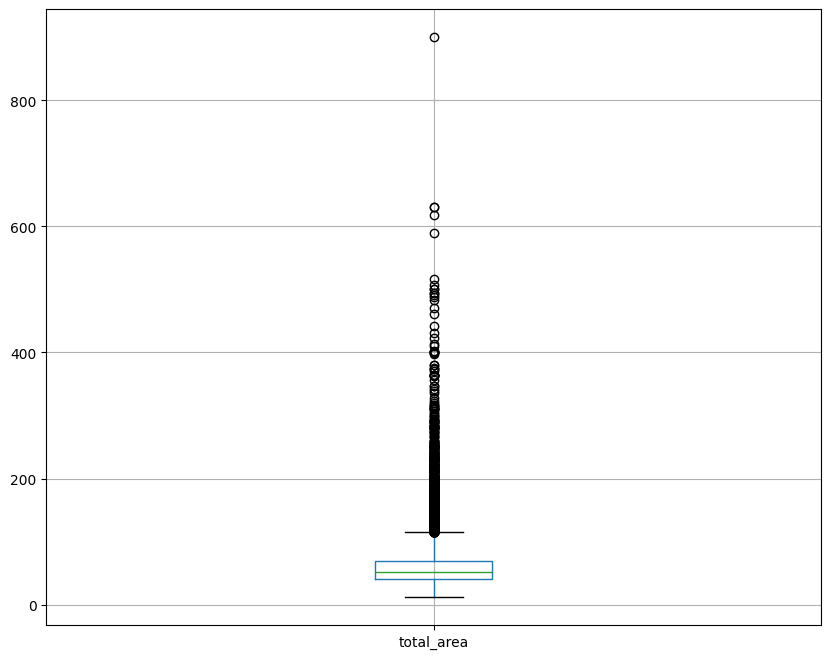

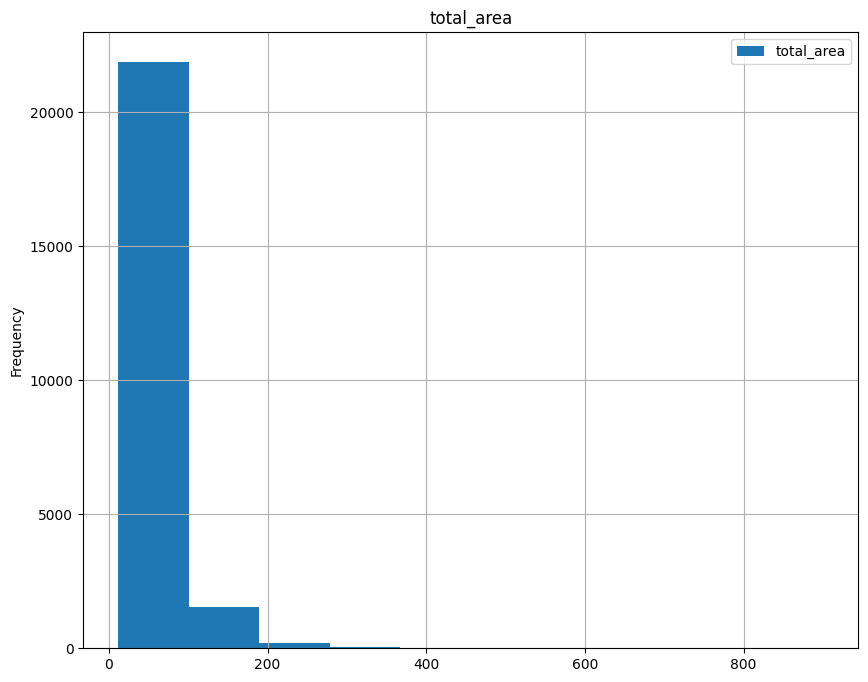

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64


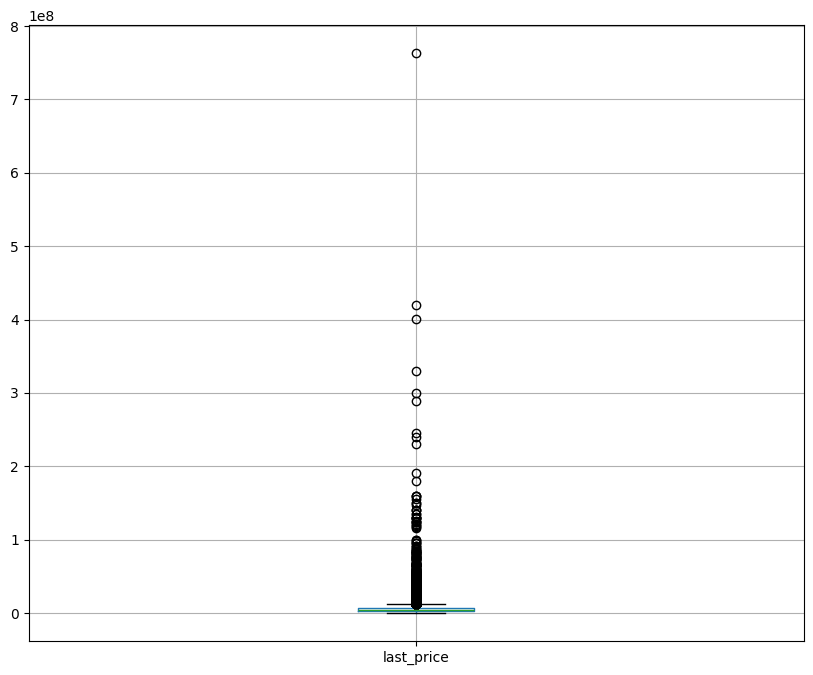

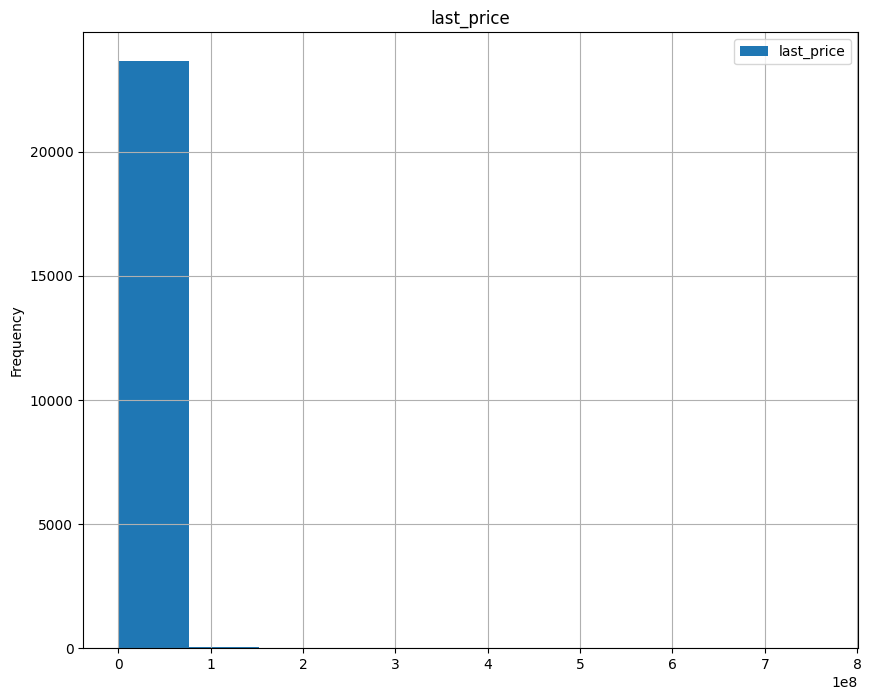

count    2.369900e+04
mean     6.541549e+06
std      1.088701e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64


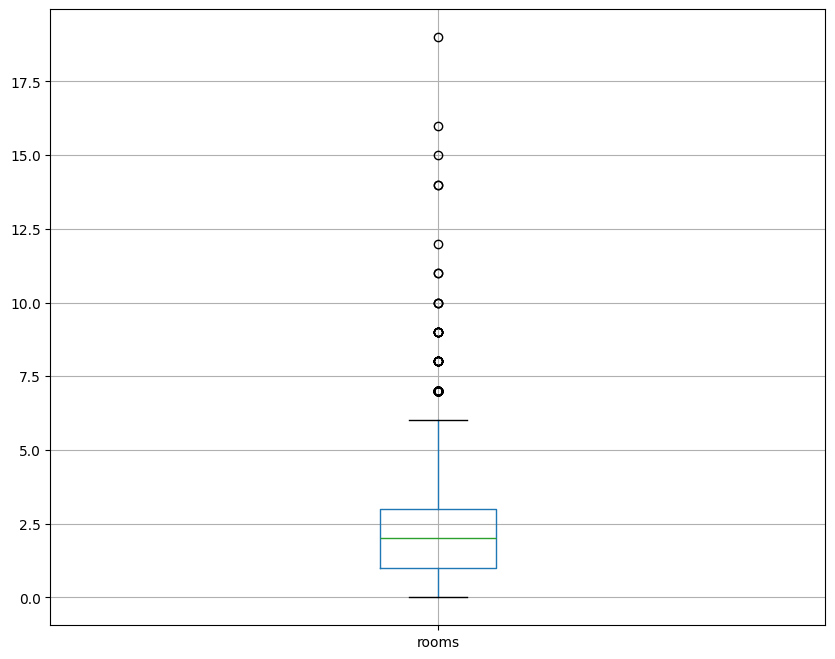

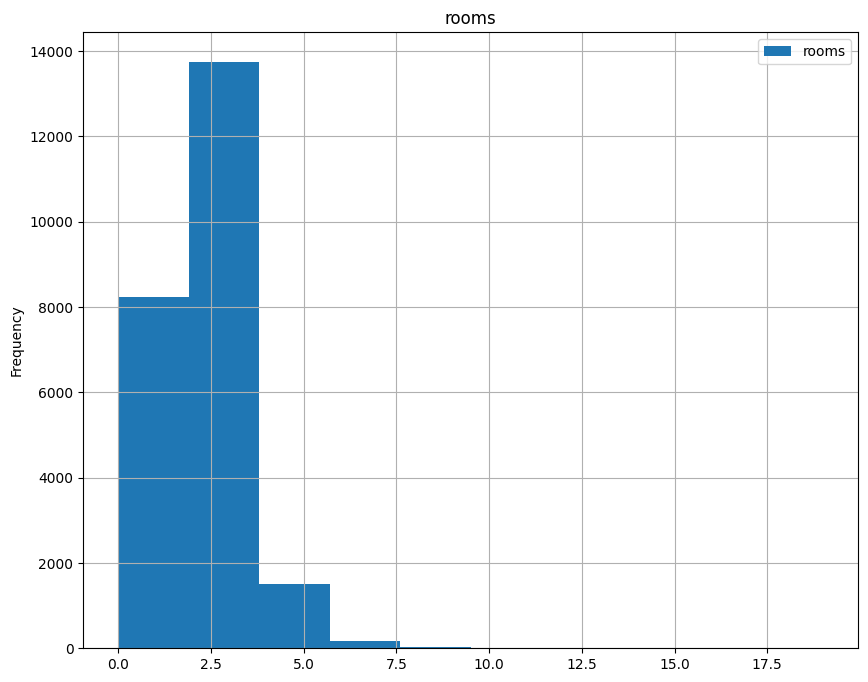

count    23699.000000
mean         2.070636
std          1.078405
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64


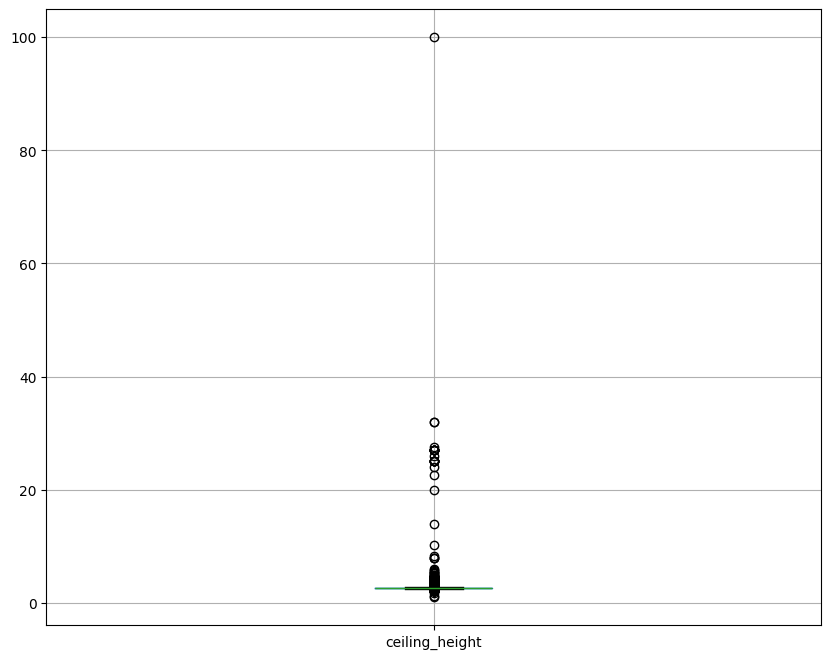

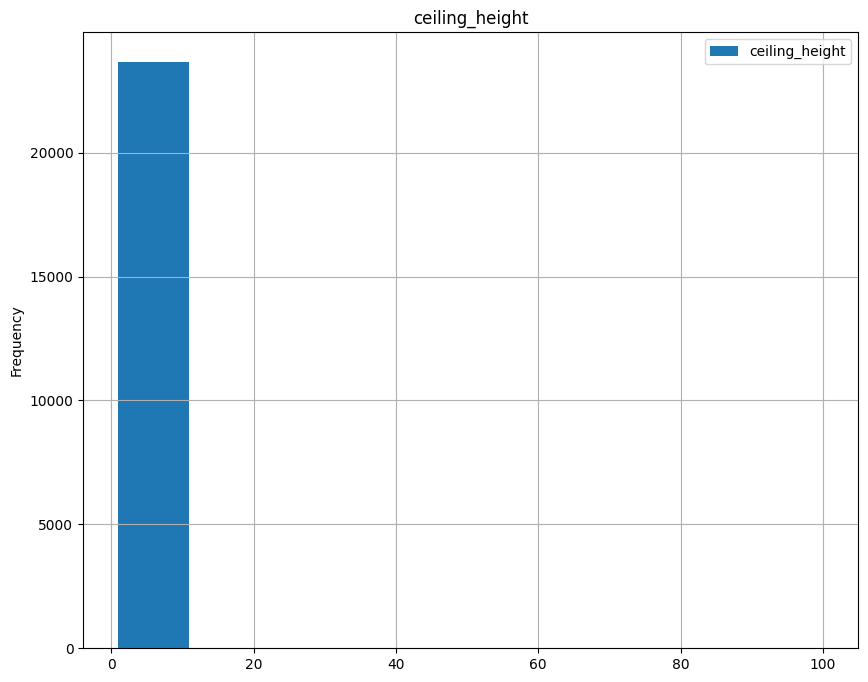

count    23699.000000
mean         2.724358
std          0.988298
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64


In [18]:
for column in ['total_area', 'last_price', 'rooms', 'ceiling_height']:
    data.boxplot(column=column, figsize=(10,8))
    plt.show()

    data.plot(kind='hist',
              y=column,
              grid=True,
              title=column,
              figsize=(10,8))
    
    plt.show()

    print(data[column].describe())




**Результаты исследования гистограмм**

1. Общая площадь:

  *  среднее значение площади = 60 м^2

  * размах от 12 м^2 до 900 м^2, можно предположить, что 12 м^2 это общежите, а 900 м^2 это элитное жилье

2. Стоимость недвижимости:

  *  медианная стоимость = 4,65 млн.

  * минимальная стоимость = 13000, недвижиность дешевле 1 млн. в рамках данного исследования будем считать выбросом, недвижимость дороже 20 млн. в рамках данного исследования будем считать выбросом

3. Количество комнат:

  *  медианное число комнат = 2

  *  минимальное число комнат = 0 - студии

  *  помещения количество комнат в которых более 8 в рамках данного исследования будем считать выбросом

4. Высота потолков:

  *  медианная высота = 2.65 м

  *  минимальная высота = 1 м

  *  помещения с высотой потолка менее 2,5 м в рамках данного исследования будем считать выбросом, помещения с высотой потолка менее 5 м в рамках данного исследования будем считать выбросом

* Изучите время продажи квартиры. Постройте гистограмму. Посчитайте среднее и медиану. Опишите, сколько обычно занимает продажа. Когда можно считать, что продажи прошли очень быстро, а когда необычно долго?



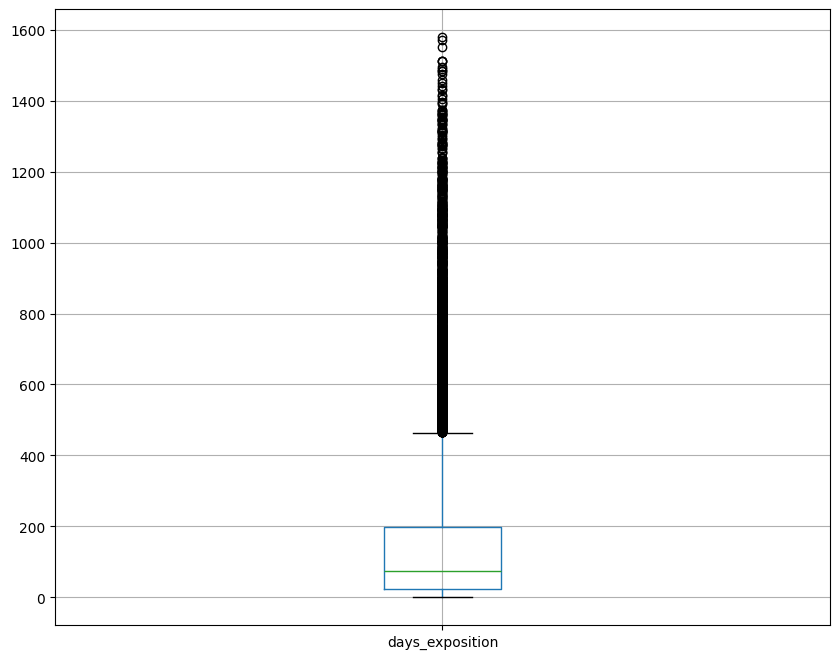

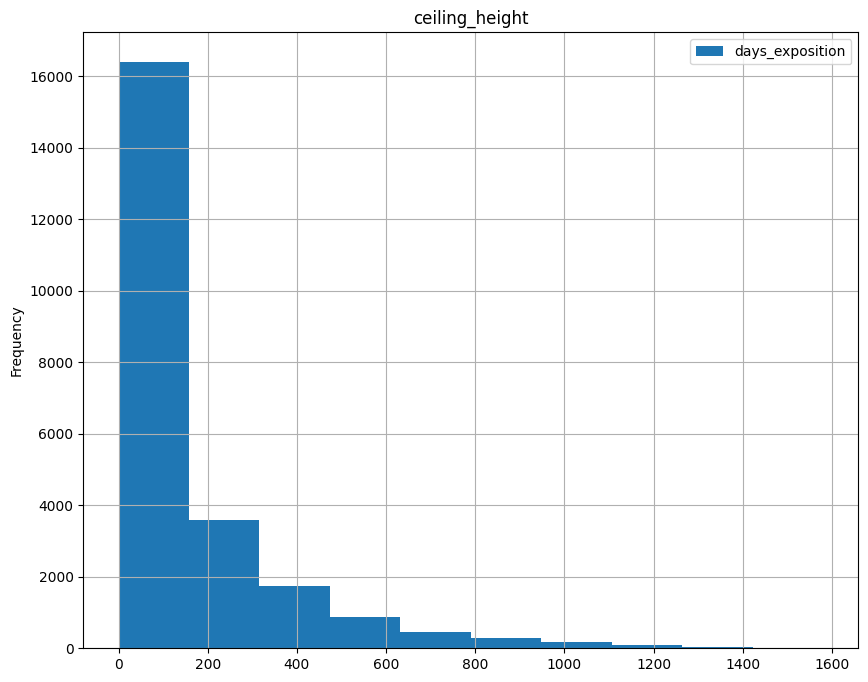

count    23699.000000
mean       156.608844
std        213.546873
min          0.000000
25%         22.000000
50%         74.000000
75%        199.000000
max       1580.000000
Name: days_exposition, dtype: float64

In [19]:
data.boxplot(column='days_exposition', figsize=(10,8))
plt.show()

data.plot(kind='hist',
              y='days_exposition',
              grid=True,
              title=column,
              figsize=(10,8))
    
plt.show()

data['days_exposition'].describe()



1. среднее время продажи недвижимости = 157 дней

2. медианное время продажи недвижимости = 73 дня

3. нормальным временем продажи недвижимости можно считать продажу от 22 до 213 дней.

4. быстрой продажей можно считать продажу длительностью до 22 дней.

5. долгой можно считать продажу длительностью более 213 дней
data['days_exposition'] = 0 в дальнейшем не рассматривать, т.к. данная недвижимость еще не продана

* Уберите редкие и выбивающиеся значения. Опишите, какие особенности обнаружили.



In [20]:
data_view = data.query('(total_area <= 450) '
                       'and (10**6 <= last_price <= 20**6) '
                       'and (rooms < 15) '
                       'and (2.5 <= ceiling_height <= 5)')

print((data.shape[0] - data_view.shape[0]) / data.shape[0] )

0.018313008987721


* Какие факторы больше всего влияют на стоимость квартиры? Изучите, зависит ли цена от площади, числа комнат, удалённости от центра. Изучите зависимость цены от того, на каком этаже расположена квартира: первом, последнем или другом. Также изучите зависимость от даты размещения: дня недели, месяца и года.



Взаимосвязь стоимости недвижимости c общей площадью, количеством комнат, расстоянием от центра

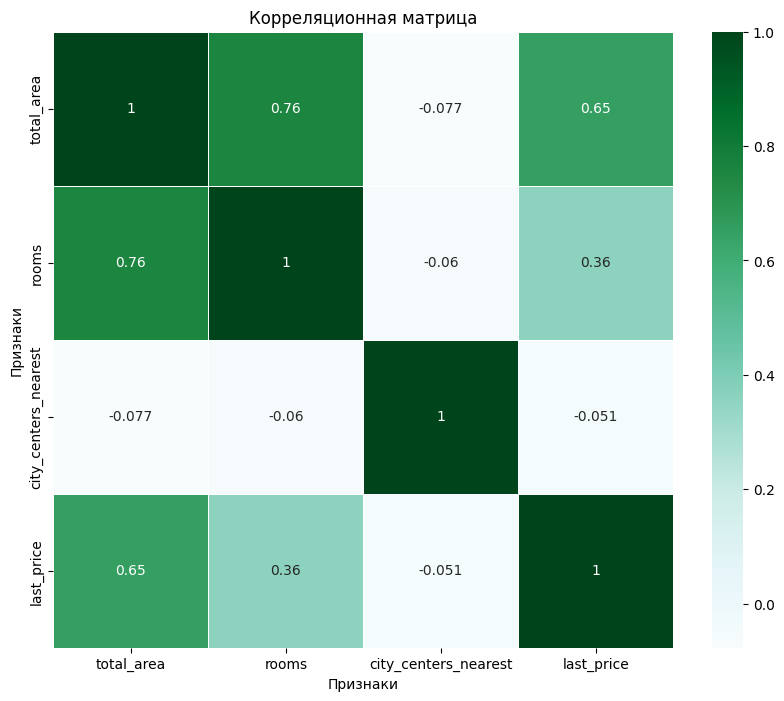

In [35]:
# Создаем фигуру и ось
fig, ax = plt.subplots(figsize=(10,8))

# Строим корреляционную матрицу
corr_matrix = data[['total_area', 'rooms', 'city_centers_nearest', 'last_price']].corr()

# Рисуем heatmap
sns.heatmap(corr_matrix, 
           annot=True, 
           cmap=sns.color_palette("BuGn", as_cmap=True),
           linewidths=0.5,
           ax=ax)

# Задаем заголовок и оси
ax.set_title("Корреляционная матрица")
ax.set_xlabel("Признаки")
ax.set_ylabel("Признаки")

# Показываем только один график
plt.show()



Взаимосвязь стоимости недвижимости c этажом на котором расположена недвижимость

In [45]:
floor_price_pivot = data_view.pivot_table(index='flat_floor', values='last_price', aggfunc=['sum','mean'])
floor_price_pivot.columns = ['sum_last_price', 'mean']

Имена встроенных палитр Seaborn:
   - "Blues", "Reds", "Greens", "Purples", "Oranges", "Greys"
   - "viridis", "plasma", "inferno", "magma", "cividis"
   - "Spectral", "coolwarm", "RdBu", "PiYG", "PRGn"

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\204476314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=floor_price_pivot.index,


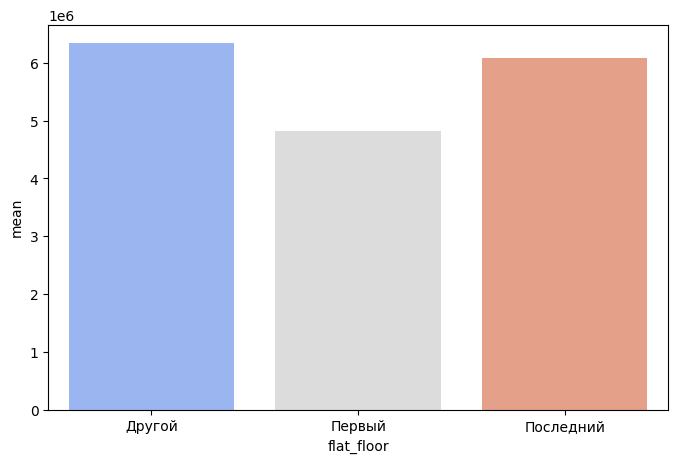

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=floor_price_pivot.index,
            y=floor_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Взаимосвязь стоимости недвижимости c днем продажи недвижимости

In [50]:
weekday_price_pivot = data_view.pivot_table(index='weekday', values='last_price', aggfunc=['sum', 'mean'])
weekday_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\1563868570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_price_pivot.index,


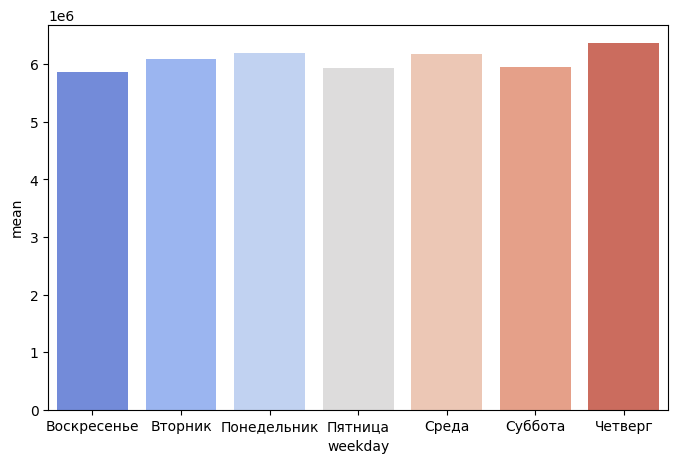

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=weekday_price_pivot.index,
            y=weekday_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Взаимосвязь стоимости недвижимости c месяцем продажи недвижимости

In [53]:
month_price_pivot = data_view.pivot_table(index='month', values='last_price', aggfunc=['sum', 'mean'])
month_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\1906123530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_price_pivot.index,


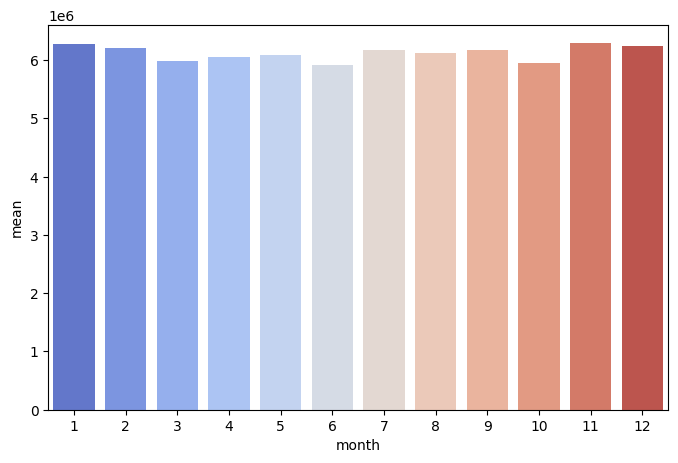

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=month_price_pivot.index,
            y=month_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Взаимосвязь стоимости недвижимости c годом продажи недвижимости

In [57]:
year_price_pivot = data_view.pivot_table(index='year', values='last_price', aggfunc=['sum', 'mean'])
year_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\1383447173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_price_pivot.index,


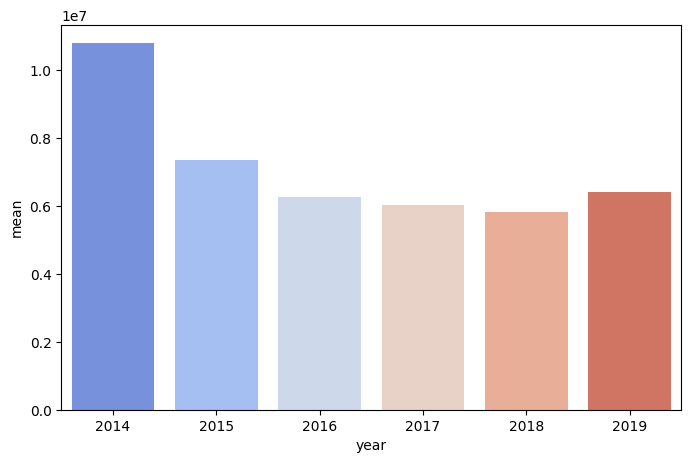

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=year_price_pivot.index,
            y=year_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

## Выводы

1. Связь стоимости недвижимости с общей площадью: сильная положительная связь - рост площади ведет к росту стоимости.

2. Связь стоимости недвижимости с количеством комнат: слабая положительная связь - рост количества ведет к росту стоимости. При этом видна сильная положительная связь количества комнат с общей площадью.

3. Связь стоимости недвижимости с расстоянием от центра: слабая отрицательная связь - увеличение расстояния ведет к уменьшению стоимости.

4. Связь стоимости недвижимости с этажом: недвижимость расположенная на первом этаже дешевле.

5. Связь стоимости недвижимости с днем продажи: не обнаружена.

6. Связь стоимости недвижимости с месяцем продажи: не обнаружена.

7. Связь стоимости недвижимости с годом продажи: с 2014 года стоимость недвижимости снижалась, в 2019 начался замечен небольшой рост стоимости.

* Выберите 10 населённых пунктов с наибольшим числом объявлений. Посчитайте среднюю цену квадратного метра в этих населённых пунктах. Выделите среди них населённые пункты с самой высокой и низкой стоимостью жилья. Эти данные можно найти по имени в столбце 'locality_name'.

In [79]:
for_top_pivot = data_view.pivot_table(index='locality_name', values='square_meter_price', aggfunc=['mean', 'count'])
for_top_pivot.columns = ['mean_price', 'count']
top_10_pivot = for_top_pivot.sort_values(by='count', ascending=False).head(10)
display(top_10_pivot.sort_values(by='mean_price', ascending=False))

,mean_price,count
locality_name,,
санкт-петербург,112637.700444,15612
пушкин,103147.825574,366
деревня кудрово,92473.547559,299
парголово,90205.423374,326
мурино,86064.821173,588
шушары,78677.364318,440
колпино,75443.972849,337
гатчина,68947.384098,305
всеволожск,68784.461187,396


Вывод:

Высокая средняя стоимость у Санкт-Петирбурга, Пушкина и Кудрова, низкая у Гатчина, Всеволожск, Выборг.

* Изучите предложения квартир: для каждой квартиры есть информация о расстоянии до центра. Выделите квартиры в Санкт-Петербурге ('locality_name'). Ваша задача — выяснить, какая область входит в центр. Создайте столбец с расстоянием до центра в километрах: округлите до целых значений. После этого посчитайте среднюю цену для каждого километра. Постройте график: он должен показывать, как цена зависит от удалённости от центра. Определите границу, где график сильно меняется — это и будет центральная зона.

In [80]:
data_view['city_centers_km'] = (data_view['city_centers_nearest'] / 1000).round()

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\3060084636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_view['city_centers_km'] = (data_view['city_centers_nearest'] / 1000).round()


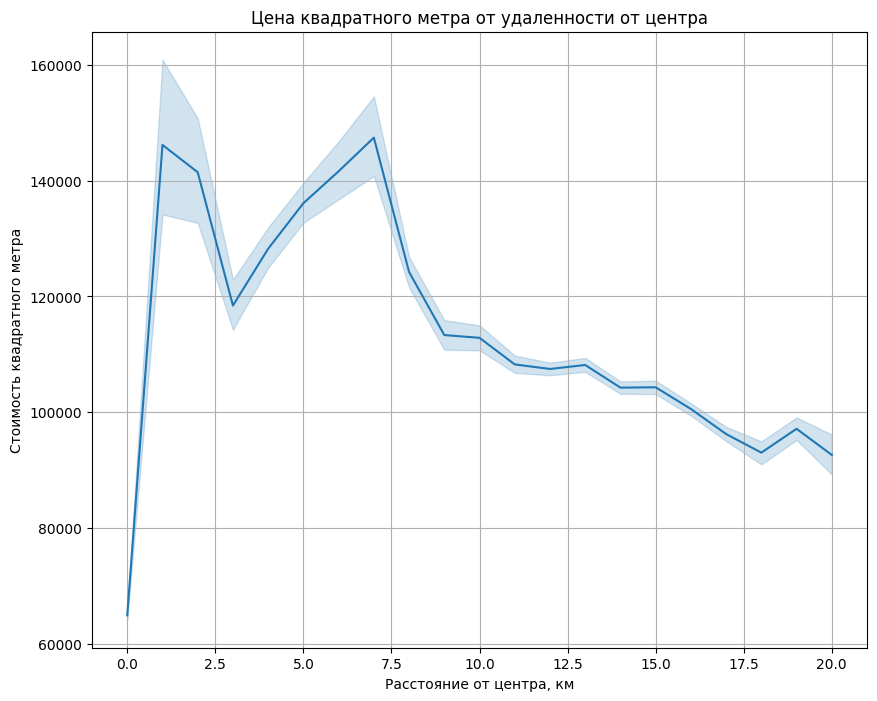

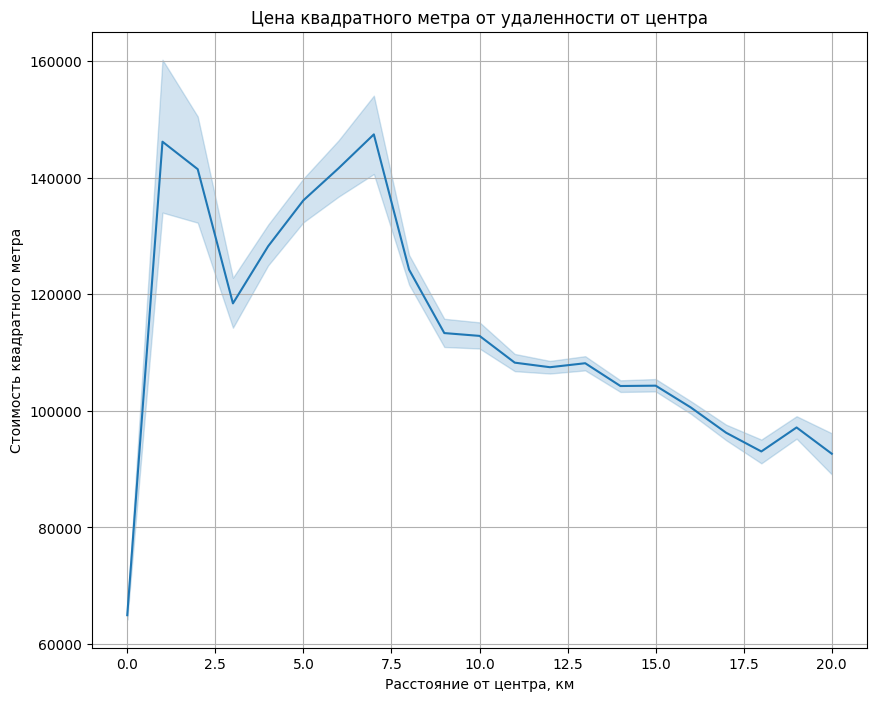

In [82]:
fig, ax = plt.subplots(figsize=(10,8))
sns.lineplot(data=data_view.query('city_centers_km <= 20'),
             x='city_centers_km',
             y='square_meter_price')
plt.grid()
plt.title('Цена квадратного метра от удаленности от центра')
plt.xlabel('Расстояние от центра, км')
plt.ylabel('Стоимость квадратного метра')

plt.show()

In [83]:
data_center = data_view.query('city_centers_km <= 8')

* Выделите сегмент квартир в центре. Проанализируйте эту территорию и изучите следующие параметры: площадь, цена, число комнат, высота потолков. Также выделите факторы, которые влияют на стоимость квартиры (число комнат, этаж, удалённость от центра, дата размещения объявления). Сделайте выводы. Отличаются ли они от общих выводов по всему городу?

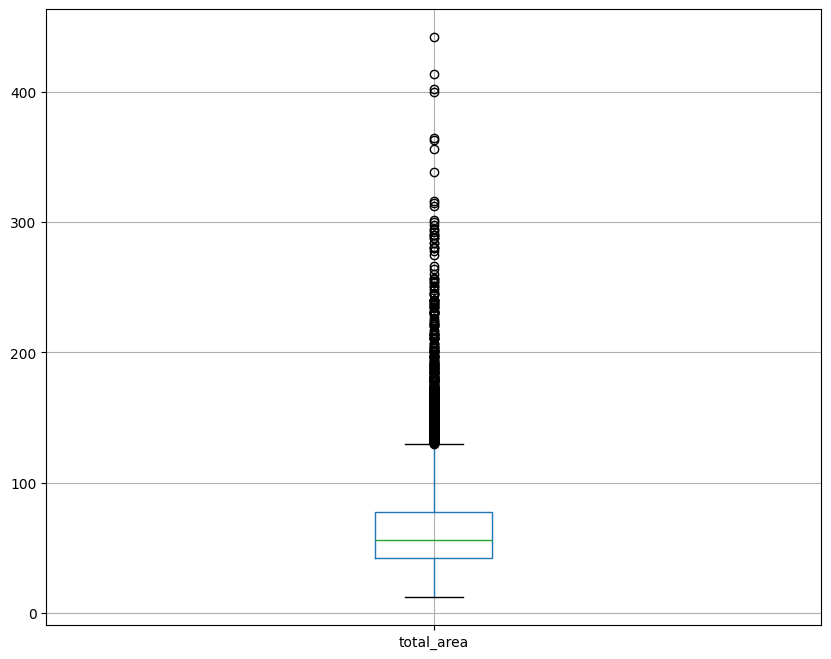

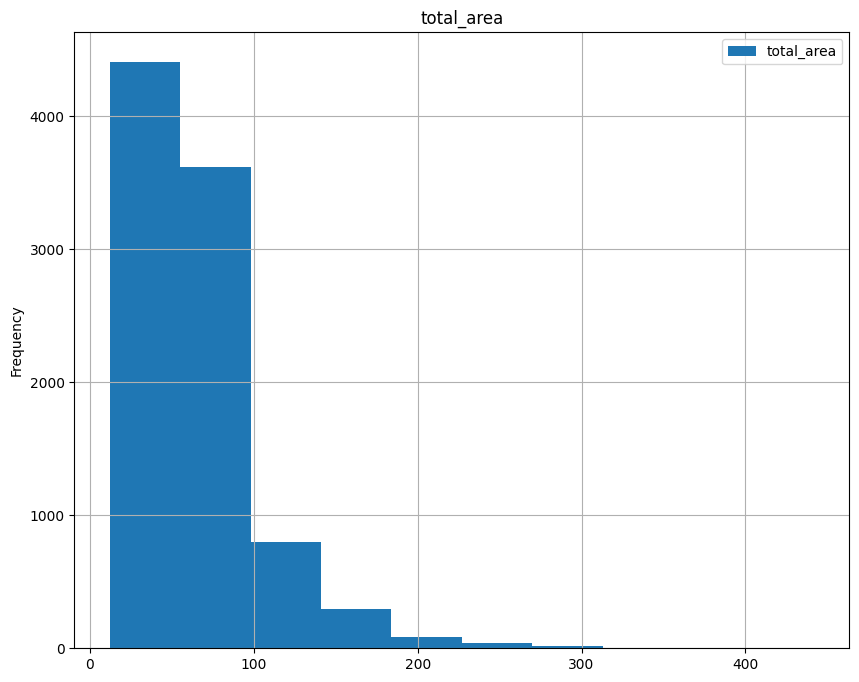

count    9279.000000
mean       65.809645
std        37.453795
min        12.000000
25%        42.000000
50%        56.000000
75%        77.000000
max       441.980000
Name: total_area, dtype: float64


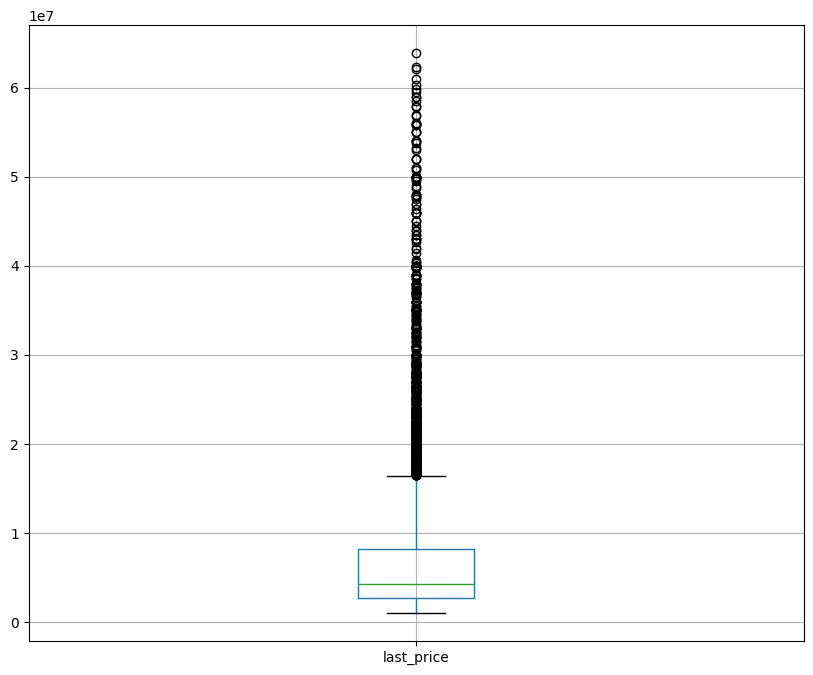

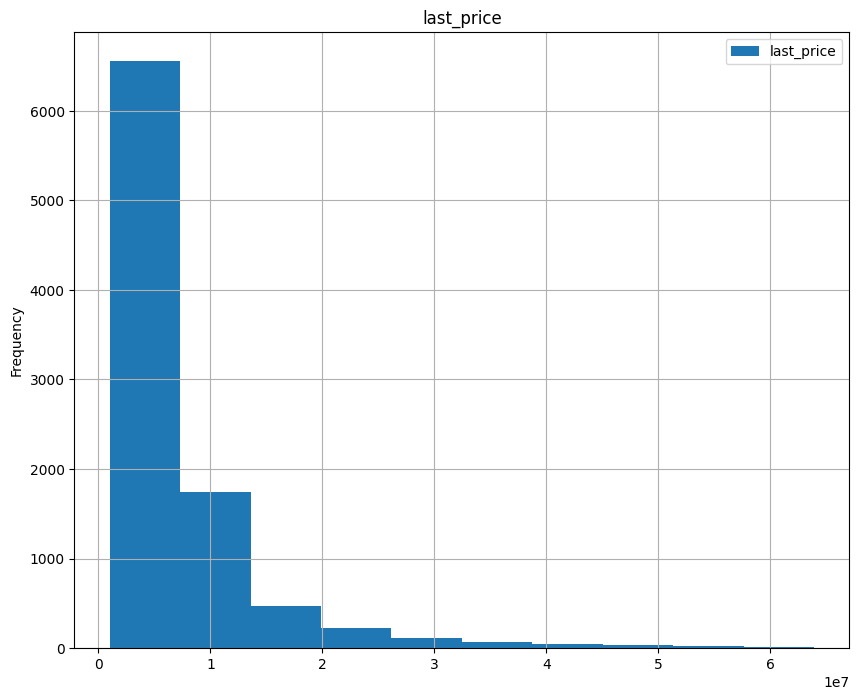

count    9.279000e+03
mean     6.872521e+06
std      7.346504e+06
min      1.000000e+06
25%      2.700000e+06
50%      4.300000e+06
75%      8.200000e+06
max      6.390000e+07
Name: last_price, dtype: float64


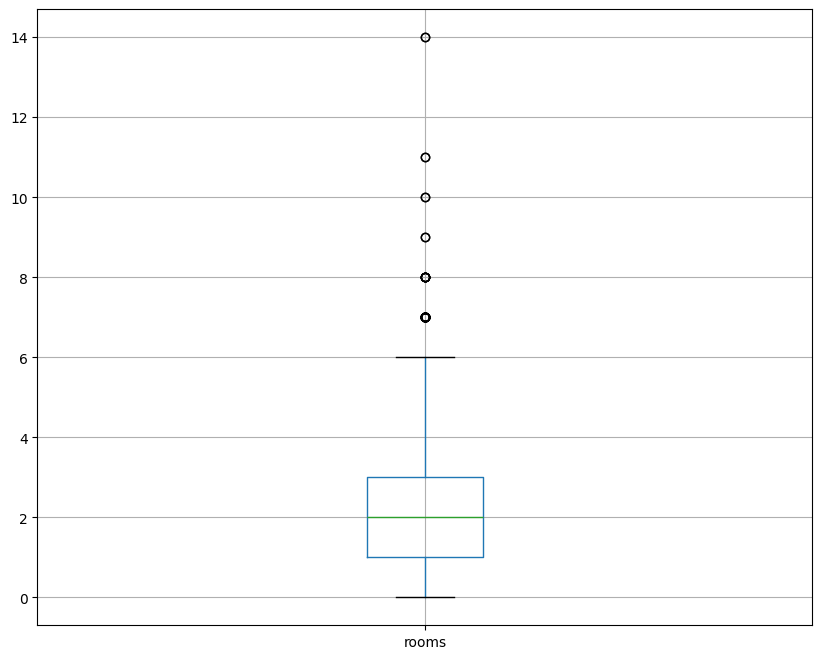

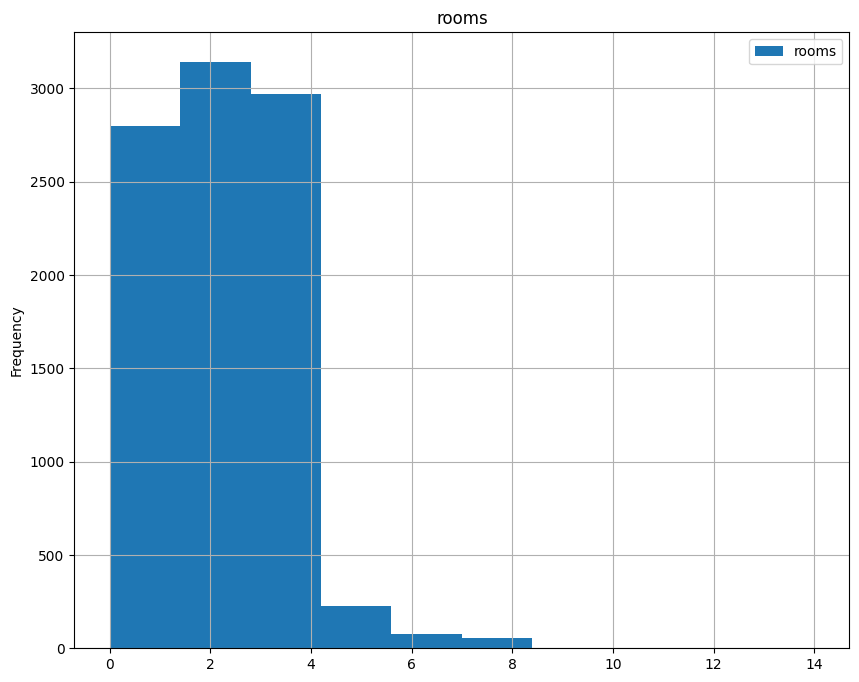

count    9279.000000
mean        2.220067
std         1.178077
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        14.000000
Name: rooms, dtype: float64


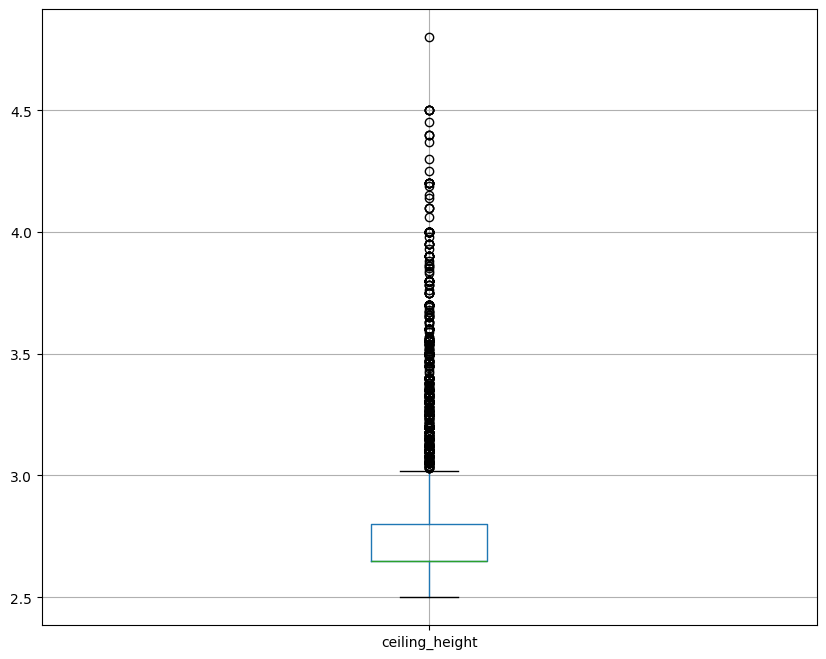

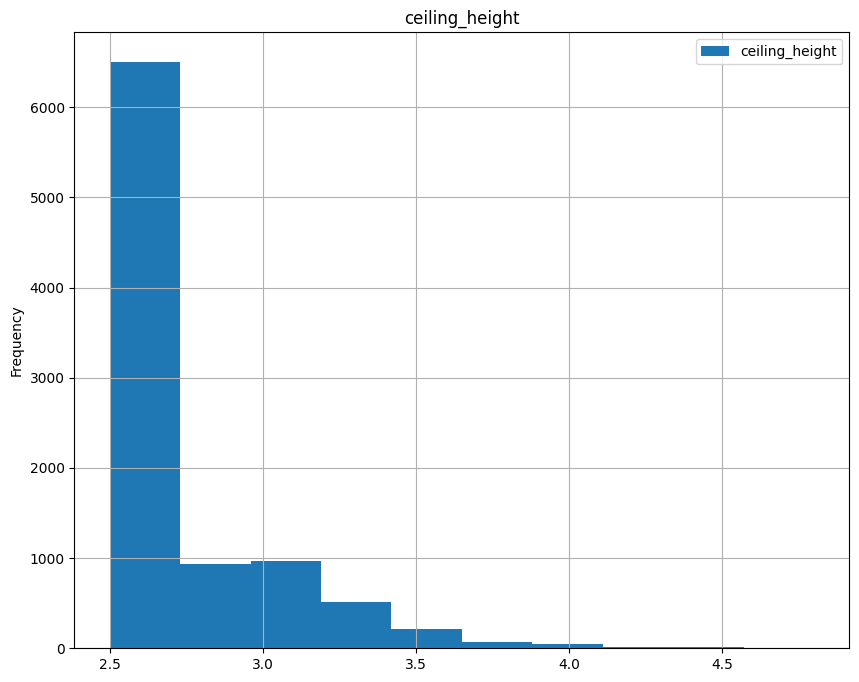

count    9279.000000
mean        2.758906
std         0.274495
min         2.500000
25%         2.650000
50%         2.650000
75%         2.800000
max         4.800000
Name: ceiling_height, dtype: float64


In [84]:
for column in ['total_area', 'last_price', 'rooms', 'ceiling_height']:
    data_center.boxplot(column=column, figsize=(10,8))
    plt.show()

    data_center.plot(kind='hist',
                     y=column,
                     grid=True,
                     title=column,
                     figsize=(10,8))
    plt.show()

    print(data_center[column].describe())

Выводы:

1. Общая площадь:

  *  среднее значение площади = 89 м^2

  * медианное значение площади = 81 м^2

2. Стоимость недвижимости:

  *  средняя стоимость = 11,3 млн.

  * медианная стоимость = 9 млн.

3. Количество комнат:

  *  среднее число комнат = 3

  *  медианное число комнат = 3

  *  минимальное число комнат = 0 - студии

4. Высота потолков:

  *  средняя высота = 3 м

  *  медианная высота = 3

  *  минимальная высота = 2.5 м

Взаимосвязь стоимости недвижимости c общей площадью, количеством комнат, расстоянием от центра

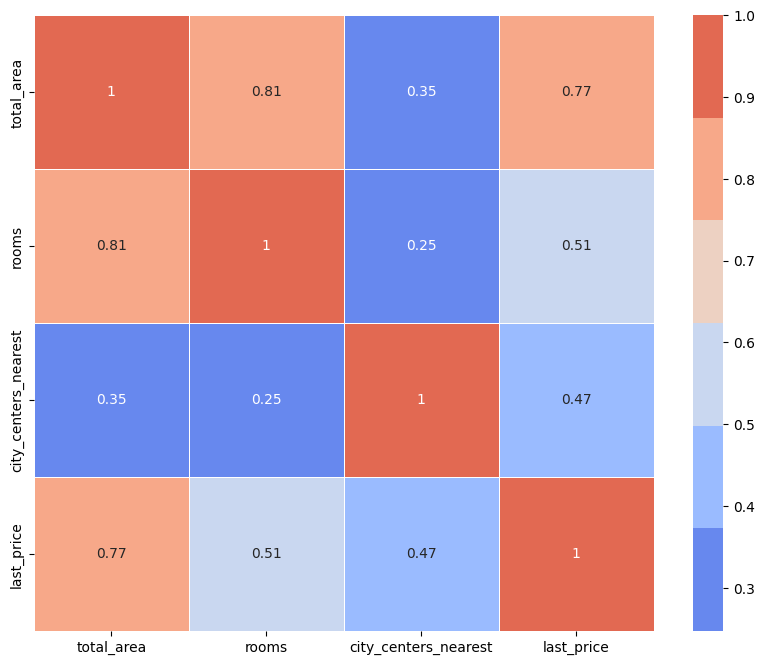

In [85]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(data=data_center[['total_area', 'rooms', 'city_centers_nearest', 'last_price']].corr(),
            annot=True,
            cmap= sns.color_palette(palette="coolwarm"),
            linewidths=0.5)
plt.show()

Взаимосвязь стоимости недвижимости c этажом на котором расположена недвижимость

In [86]:
center_floor_price_pivot = data_center.pivot_table(index='flat_floor', values='last_price', aggfunc=['sum','mean'])
center_floor_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\2233230699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=center_floor_price_pivot.index,


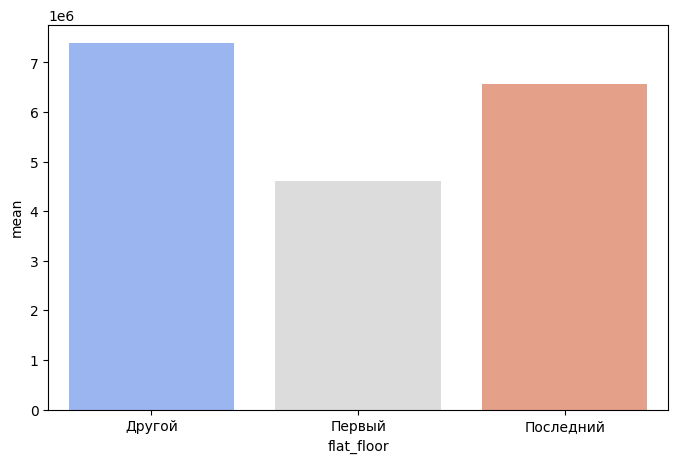

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=center_floor_price_pivot.index,
            y=center_floor_price_pivot['mean'],
            palette="coolwarm",            
            ax=ax)

plt.show()

Взаимосвязь стоимости недвижимости c днем продажи недвижимости

In [88]:
center_weekday_price_pivot = data_center.pivot_table(index='weekday', values='last_price', aggfunc=['sum', 'mean'])
center_weekday_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\1682174295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=center_weekday_price_pivot.index,


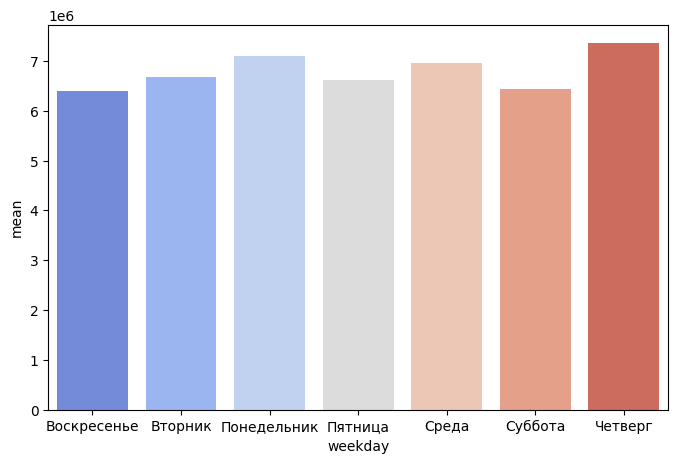

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=center_weekday_price_pivot.index,
            y=center_weekday_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Взаимосвязь стоимости недвижимости c месяцем продажи недвижимости

In [90]:
center_month_price_pivot = data_center.pivot_table(index='month', values='last_price', aggfunc=['sum', 'mean'])
center_month_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\4243751631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=center_month_price_pivot.index,


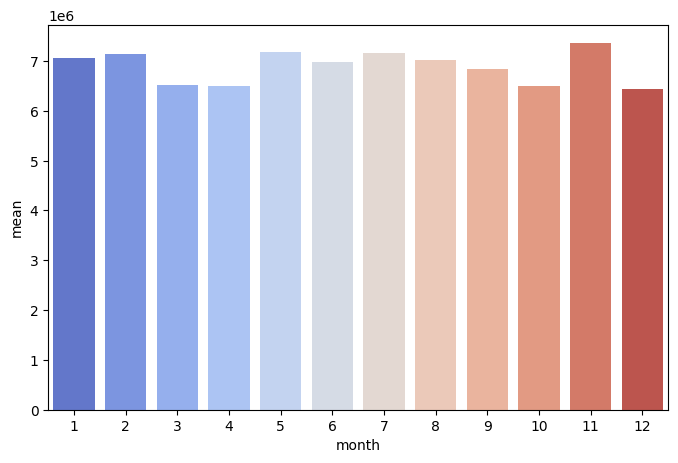

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=center_month_price_pivot.index,
            y=center_month_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Взаимосвязь стоимости недвижимости c годом продажи недвижимости

In [92]:
center_year_price_pivot = data_center.pivot_table(index='year', values='last_price', aggfunc=['sum', 'mean'])
center_year_price_pivot.columns = ['sum_last_price', 'mean']

C:\Users\yuliy\AppData\Local\Temp\ipykernel_3400\1383447173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_price_pivot.index,


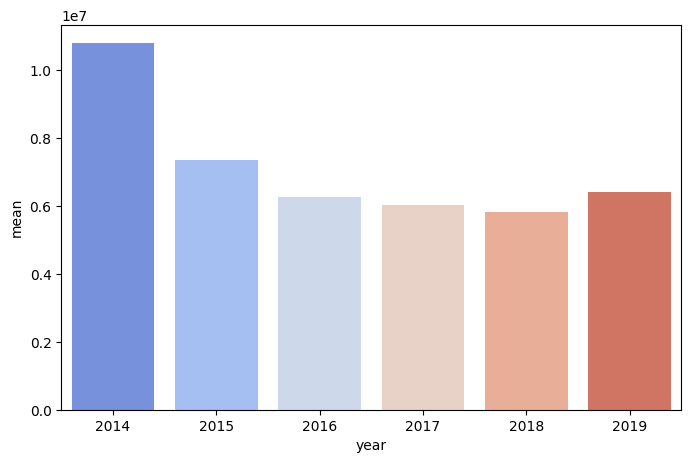

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=year_price_pivot.index,
            y=year_price_pivot['mean'],
            palette="coolwarm",
            ax=ax)
plt.show()

Вывод:

1. Связь стоимости недвижимости с общей площадью: сильная положительная связь - рост площади ведет к росту стоимости.

2. Связь стоимости недвижимости с количеством комнат: слабая положительная связь - рост количества ведет к росту стоимости. При этом видна сильная положительная связь количества комнат с общей площадью.

3. Связь стоимости недвижимости с расстоянием от центра:  слабая отрицательная связь - увеличение расстояния ведет к уменьшению стоимости, связь слабее чем в целом по представленным населенным пунктам.

4. Связь стоимости недвижимости с этажом: недвижимость расположенная на первом этаже дешевле.

5. Связь стоимости недвижимости с днем продажи: стоимость недвижимости проданной в четверг выше чем в остальные дни. Возможно связанно с тем, что оформление происходит в буднии дни

6. Связь стоимости недвижимости с месяцем продажи: стоимость недвижимости проданной в декабре выше чем в другие месяцы. Возможно связанно с активной покупательской способностью перед новым годом.

7. Связь стоимости недвижимости с годом продажи: с 2014 года стоимость недвижимости снижалась, в 2019 начался замечен небольшой рост стоимости

**Шаг 5. Напишите общий вывод**

1. Факторы влияющие на стоимость недвижимости(в центре, остальной части города):

  * площадь. Положительное влияние.

  * количество комнат. Положительное влияние. Связан с площадью.

  * расстояние до центра. Отрицательное влияние.

  * высота потолков. Положительное влияние.

  * этаж. Недвижимость на первом этаже дешевле.

2. Дата продажи:

  * самая высокая стоимость в 2014 году

  * уменьшение стоимости до 2018 года

  * рост стоимости в 2019 году

3. Населенные пунты:

  * высокая стоимость недвижимости в: Пушкине, Санкт-Петирбурге, Кудрова.
  
  * низкая в Гатчине, Всеволожске, Выборге.
